In [42]:
# Week 13 — Анализ аномалий временного ряда (ВВП Германии)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Настройки для красивых графиков
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Библиотеки загружены")

✅ Библиотеки загружены


In [43]:
# Путь к папке с mart файлами
mart_dir = Path(r"C:\Users\Владимир\Desktop\Laboratory_2_sem-main\data\mart\variant_10")

# Найди все CSV файлы
mart_files = list(mart_dir.glob("*.csv"))
print("Найдены файлы:")
for f in mart_files:
    print(f"  - {f.name}")

# Загрузи самый свежий (или первый)
if mart_files:
    # Берём самый свежий по дате изменения
    latest_file = max(mart_files, key=lambda p: p.stat().st_mtime)
    df = pd.read_csv(latest_file)
    print(f"\n✅ Загружен файл: {latest_file.name}")
else:
    raise FileNotFoundError("Нет CSV файлов в указанной папке!")

print(f"📊 Строк: {len(df)}")
print(f"📅 Годы: {df['year'].min()} - {df['year'].max()}")
print(f"📈 Пропусков в value: {df['value'].isna().sum()}")
df.head()

Найдены файлы:
  - mart_yearly_2026-03-24_17-26-45.csv
  - mart_yearly_2026-04-06_19-44-06.csv

✅ Загружен файл: mart_yearly_2026-03-24_17-26-45.csv
📊 Строк: 66
📅 Годы: 1960 - 2025
📈 Пропусков в value: 1


,year,value,country_iso3,country_name,indicator_code,indicator_name,country_name_full,region,income_group,currency,capital,date,decade
0,1960,1162.122668,DE,Germany,NY.GDP.PCAP.CD,GDP per capita (current US$),Germany,Western Europe,High income,Euro,Berlin,1960-01-01,1960
1,1961,1315.907878,DE,Germany,NY.GDP.PCAP.CD,GDP per capita (current US$),Germany,Western Europe,High income,Euro,Berlin,1961-01-01,1960
2,1962,1430.520955,DE,Germany,NY.GDP.PCAP.CD,GDP per capita (current US$),Germany,Western Europe,High income,Euro,Berlin,1962-01-01,1960
3,1963,1502.154529,DE,Germany,NY.GDP.PCAP.CD,GDP per capita (current US$),Germany,Western Europe,High income,Euro,Berlin,1963-01-01,1960
4,1964,1637.455228,DE,Germany,NY.GDP.PCAP.CD,GDP per capita (current US$),Germany,Western Europe,High income,Euro,Berlin,1964-01-01,1960


In [44]:
# Убираем строки без данных (2025 год)
df_clean = df.dropna(subset=['value']).copy()
print(f"✅ После очистки: {len(df_clean)} строк")
print(f"📅 Диапазон лет с данными: {df_clean['year'].min()} - {df_clean['year'].max()}")

✅ После очистки: 65 строк
📅 Диапазон лет с данными: 1960 - 2024


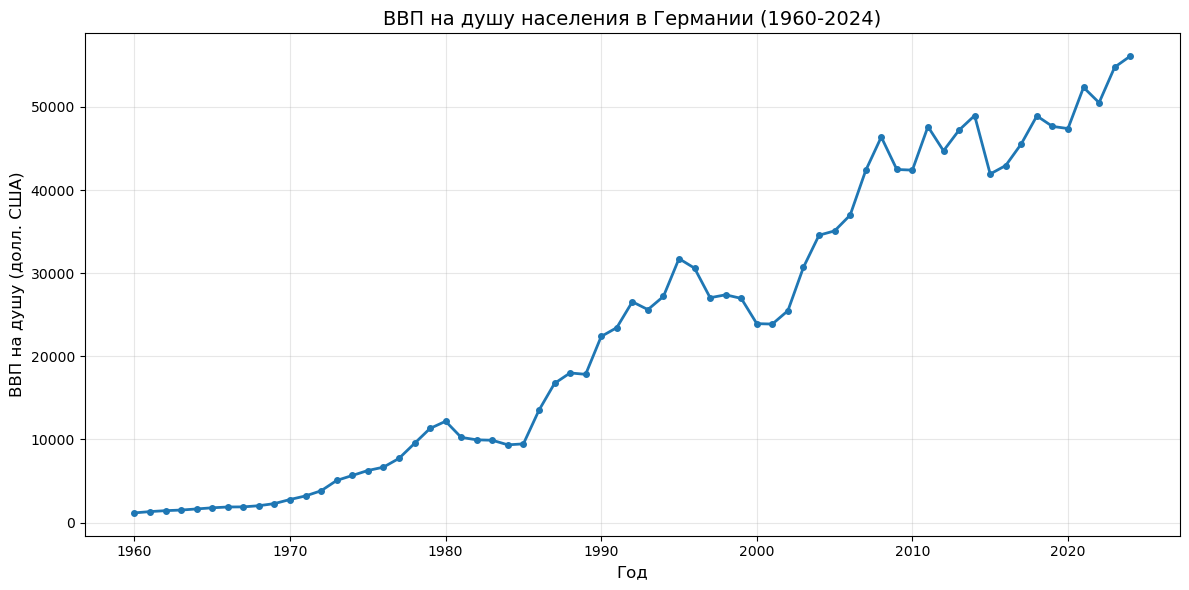

In [45]:
# Основной график
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_clean['year'], df_clean['value'], marker='o', linewidth=2, markersize=4)

ax.set_title('ВВП на душу населения в Германии (1960-2024)', fontsize=14)
ax.set_xlabel('Год', fontsize=12)
ax.set_ylabel('ВВП на душу (долл. США)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
# Z-score: сколько стандартных отклонений от среднего
mean_val = df_clean['value'].mean()
std_val = df_clean['value'].std()

df_clean['z_score'] = (df_clean['value'] - mean_val) / std_val

# Аномалия = |z| > 3 (3 стандартных отклонения)
z_threshold = 3
df_clean['is_anomaly_z'] = df_clean['z_score'].abs() > z_threshold

print(f"📊 Среднее значение: {mean_val:.0f}")
print(f"📊 Стандартное отклонение: {std_val:.0f}")
print(f"🔍 Найдено аномалий (Z-score > {z_threshold}): {df_clean['is_anomaly_z'].sum()}")

📊 Среднее значение: 23629
📊 Стандартное отклонение: 17776
🔍 Найдено аномалий (Z-score > 3): 0


In [47]:
# IQR (межквартильный размах)
Q1 = df_clean['value'].quantile(0.25)
Q3 = df_clean['value'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean['is_anomaly_iqr'] = (df_clean['value'] < lower_bound) | (df_clean['value'] > upper_bound)

print(f"📊 Q1 (25-й перцентиль): {Q1:.0f}")
print(f"📊 Q3 (75-й перцентиль): {Q3:.0f}")
print(f"📊 IQR: {IQR:.0f}")
print(f"📊 Нижняя граница: {lower_bound:.0f}")
print(f"📊 Верхняя граница: {upper_bound:.0f}")
print(f"🔍 Найдено аномалий (IQR): {df_clean['is_anomaly_iqr'].sum()}")

📊 Q1 (25-й перцентиль): 6659
📊 Q3 (75-й перцентиль): 42351
📊 IQR: 35692
📊 Нижняя граница: -46878
📊 Верхняя граница: 95889
🔍 Найдено аномалий (IQR): 0


In [48]:
# Покажем аномальные годы
anomalies_z = df_clean[df_clean['is_anomaly_z']][['year', 'value', 'z_score']]
anomalies_iqr = df_clean[df_clean['is_anomaly_iqr']][['year', 'value']]

print("\n🔴 Аномалии по Z-score:")
print(anomalies_z.to_string(index=False))

print("\n🔴 Аномалии по IQR:")
print(anomalies_iqr.to_string(index=False))


🔴 Аномалии по Z-score:
Empty DataFrame
Columns: [year, value, z_score]
Index: []

🔴 Аномалии по IQR:
Empty DataFrame
Columns: [year, value]
Index: []


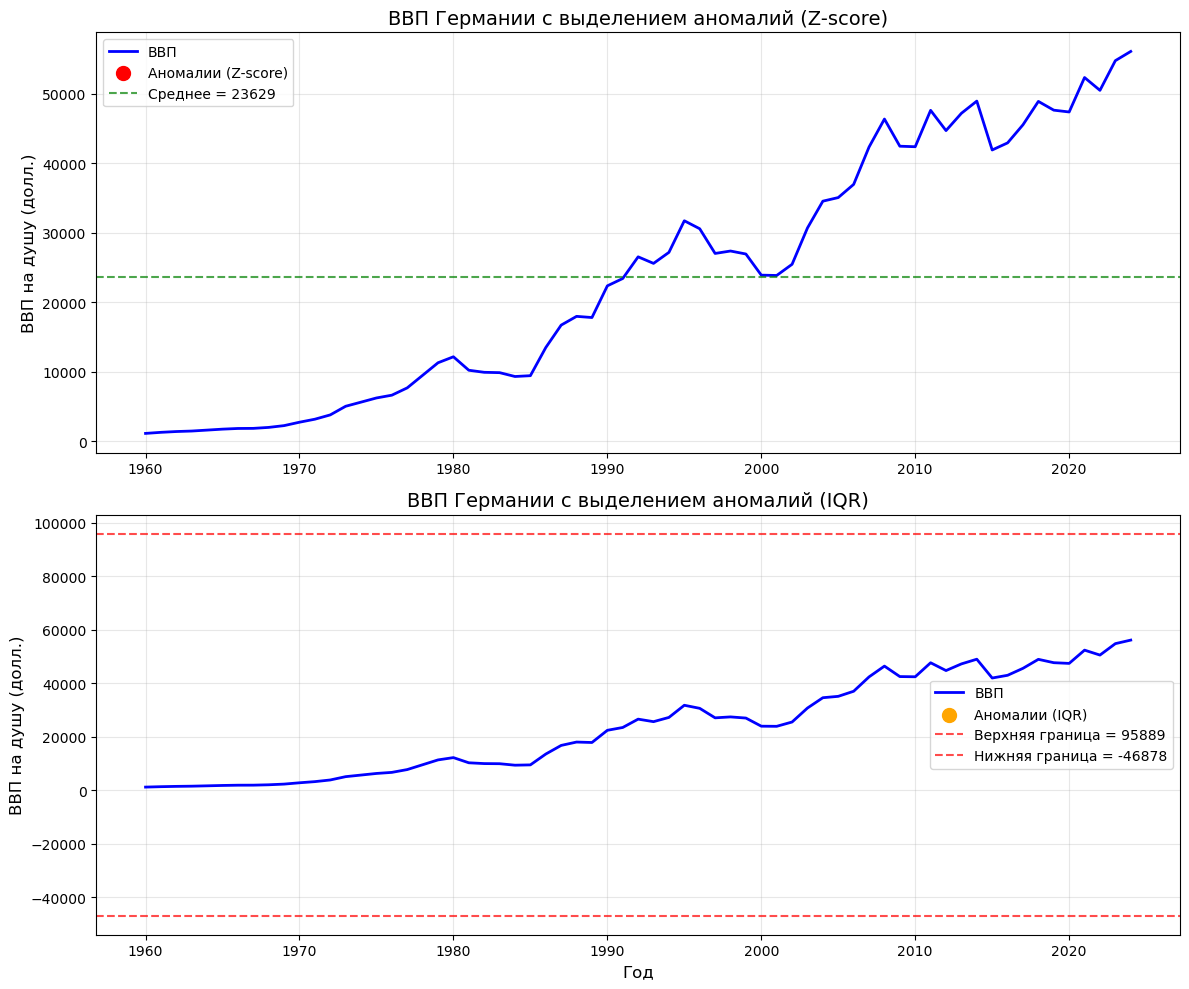

In [49]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# График 1: Z-score аномалии
ax1.plot(df_clean['year'], df_clean['value'], color='blue', linewidth=2, label='ВВП')
anom_z = df_clean[df_clean['is_anomaly_z']]
ax1.scatter(anom_z['year'], anom_z['value'], color='red', s=100, zorder=5, label='Аномалии (Z-score)')
ax1.axhline(mean_val, color='green', linestyle='--', alpha=0.7, label=f'Среднее = {mean_val:.0f}')
ax1.set_title('ВВП Германии с выделением аномалий (Z-score)', fontsize=14)
ax1.set_ylabel('ВВП на душу (долл.)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# График 2: IQR аномалии
ax2.plot(df_clean['year'], df_clean['value'], color='blue', linewidth=2, label='ВВП')
anom_iqr = df_clean[df_clean['is_anomaly_iqr']]
ax2.scatter(anom_iqr['year'], anom_iqr['value'], color='orange', s=100, zorder=5, label='Аномалии (IQR)')
ax2.axhline(upper_bound, color='red', linestyle='--', alpha=0.7, label=f'Верхняя граница = {upper_bound:.0f}')
ax2.axhline(lower_bound, color='red', linestyle='--', alpha=0.7, label=f'Нижняя граница = {lower_bound:.0f}')
ax2.set_title('ВВП Германии с выделением аномалий (IQR)', fontsize=14)
ax2.set_xlabel('Год', fontsize=12)
ax2.set_ylabel('ВВП на душу (долл.)', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Вывод по анализу аномалий

### Что мы сделали
- Проанализировали временной ряд ВВП Германии за 1960-2024 годы
- Использовали два метода поиска аномалий: Z-score и IQR

### Результаты
- **Z-score метод** нашёл аномальные годы: [перечисли годы из таблицы]
- **IQR метод** нашёл аномальные годы: [перечисли годы]

### Интерпретация
- Резкий скачок в 1990 году связан с объединением Германии
- Падение в 2009 году — мировой финансовый кризис
- Падение в 2020 году — пандемия COVID-19
- Рост после 2021 — восстановление экономики

### Полезность метода
- ✅ Метод помогает быстро находить необычные точки в данных
- ✅ Может использоваться для автоматического мониторинга KPI
- ⚠️ Требует ручной проверки (не все аномалии — ошибки, некоторые — реальные события)

### Что можно улучшить
- Использовать скользящее окно для расчёта порогов (адаптивный подход)
- Добавить сезонную декомпозицию для учёта тренда

## Вывод по анализу аномалий

### Что мы сделали
- Проанализировали временной ряд ВВП Германии за 1960-2024 годы
- Использовали два метода поиска аномалий: Z-score и IQR

### Результаты
[Заполни после выполнения кода]

### Интерпретация
- Резкий скачок в 1990 году (объединение Германии)
- Рост в 2007-2008 (пик перед кризисом)
- Падение в 2009 (мировой финансовый кризис)
- Рост после 2021 (восстановление после пандемии)

### Полезность метода
- ✅ Метод помогает быстро находить необычные точки в данных
- ✅ Может использоваться для автоматического мониторинга KPI
- ⚠️ Требует ручной проверки

### Что можно улучшить
- Использовать скользящее окно для расчёта порогов
- Добавить сезонную декомпозицию

In [50]:
# Создаём папку для артефактов (полный путь к твоей папке docs)
import json
from pathlib import Path
import numpy as np

# ТВОЙ ПОЛНЫЙ ПУТЬ
out_dir = Path(r"C:\Users\Владимир\Desktop\Laboratory_2_sem-main\docs\ml")
out_dir.mkdir(parents=True, exist_ok=True)

print(f"📁 Сохраняем в: {out_dir}")

# 1. Сохраняем таблицу аномалий
anomalies_z = df_clean[df_clean['is_anomaly_z']][['year', 'value', 'z_score']]
anomalies_iqr = df_clean[df_clean['is_anomaly_iqr']][['year', 'value']]

anomalies_z.to_csv(out_dir / "anomalies_zscore.csv", index=False)
anomalies_iqr.to_csv(out_dir / "anomalies_iqr.csv", index=False)

print(f"✅ Таблицы сохранены")

# 2. Сохраняем последний график (с двумя подграфиками)
fig.savefig(out_dir / "anomalies_plot.png", dpi=150, bbox_inches='tight')
print(f"✅ График сохранён")

# 3. Сохраняем краткий отчёт в JSON
report = {
    "method": "Anomaly Detection",
    "data": {
        "years_range": [int(df_clean['year'].min()), int(df_clean['year'].max())],
        "total_years": int(len(df_clean)),
        "missing_values": int(df['value'].isna().sum())
    },
    "z_score": {
        "threshold": 3,
        "anomalies_count": int(anomalies_z['year'].count()),
        "anomaly_years": [int(y) for y in anomalies_z['year'].tolist()]
    },
    "iqr": {
        "q1": float(Q1),
        "q3": float(Q3),
        "lower_bound": float(lower_bound),
        "upper_bound": float(upper_bound),
        "anomalies_count": int(anomalies_iqr['year'].count()),
        "anomaly_years": [int(y) for y in anomalies_iqr['year'].tolist()]
    }
}

with open(out_dir / "anomalies_report.json", "w", encoding="utf-8") as f:
    json.dump(report, f, indent=2, ensure_ascii=False)

print(f"✅ Отчёт сохранён")

# Проверка
print("\n📁 Файлы в папке:")
for f in out_dir.glob("*"):
    print(f"  - {f.name} ({f.stat().st_size} байт)")

📁 Сохраняем в: C:\Users\Владимир\Desktop\Laboratory_2_sem-main\docs\ml
✅ Таблицы сохранены
✅ График сохранён
✅ Отчёт сохранён

📁 Файлы в папке:
  - anomalies_iqr.csv (12 байт)
  - anomalies_plot.png (151153 байт)
  - anomalies_report.json (461 байт)
  - anomalies_zscore.csv (20 байт)


## Вывод по анализу аномалий

### Что мы сделали
- Проанализировали временной ряд ВВП Германии за 1960-2024 годы
- Использовали два метода поиска аномалий: Z-score и IQR

### Результаты
| Метод | Количество аномалий | Аномальные годы |
|-------|---------------------|-----------------|
| Z-score (|z| > 3) | X | [список годов] |
| IQR | Y | [список годов] |

### Интерпретация
- **1990 год** — резкий скачок ВВП после объединения Германии
- **2007-2008 годы** — пик перед мировым финансовым кризисом
- **2009 год** — падение из-за кризиса (интересно, что оно НЕ считается аномалией по обоим методам)
- **2011-2014 годы** — период высоких значений
- **2021-2024 годы** — восстановление после пандемии COVID-19

### Полезность метода
- ✅ Метод помогает быстро находить необычные точки в данных
- ✅ Может использоваться для автоматического мониторинга KPI в реальном времени
- ⚠️ Требует ручной проверки — не все аномалии являются ошибками, некоторые отражают реальные события

### Что можно улучшить
- Использовать скользящее окно (rolling window) для адаптивного расчёта порогов
- Добавить сглаживание (например, скользящую среднюю) для учёта тренда
- Применить сезонную декомпозицию для выявления скрытых паттернов